In [1]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
import numpy as np
import yaml
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

# 0. Experiment selection

In [2]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/baseline_251010_middle_2")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

Testing experiment: baseline_251010_middle_2
Device: cuda:1


In [3]:
# Load configuration files
config_path = EXPERIMENT_DIR / "config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Seed: {config['experiment']['seed']}")
print(f"- Max hits: {config['data']['max_hits']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 128
- Seed: 42
- Max hits: 500


# 1. Load trained models: basic + domain discriminator

In [4]:
# Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

print("Models loaded successfully:")
print(f"- Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"- Best metric: {checkpoint.get('best_metric', 'unknown')}")
print(f"- Base model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading checkpoint from: ../experiments/numu/baseline_251010_middle_2/best_model.pth


/tmp/ipykernel_1801578/691600931.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Models loaded successfully:
- Epoch: 43
- Best metric: 0.9751662488570363
- Base model parameters: 541,633


# 2. Load data to test on

## 2.1 Source (MC) domain

In [5]:
# Create test dataset (using source domain for classification evaluation)
source_config = config['data']
train_events_per_particle = config['data']['events_per_particle']

# Use validation portion of source data for testing (events model hasn't seen)
test_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device='cuda:1',
    shuffle_events=False
)
print(f"Test dataset created with {len(test_dataset)} events")
print(f"Particle distribution:")
for particle in source_config['particle_types']:
    count = sum(1 for i in range(len(test_dataset)) if test_dataset.event_ids[i].split(":")[0] == particle)
    print(f"  {particle}: {count:,} events")
    
    
# Create test dataloader
test_dataloader = create_numu_dataloader_from_ds(
    dataset=test_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=False,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {test_dataloader.batch_size}")
print(f"- Number of batches: {len(test_dataloader)}")
print(f"- Total events: {len(test_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

Test dataset created with 750000 events
Particle distribution:
  muatm_2020: 500,000 events
  nuatm_2020: 250,000 events
  nue2_2020: 0 events
Test dataloader created:
- Batch size: 256
- Number of batches: 2930
- Total events: 750000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]


# 3. Make predctions and extract meta-info

## 3.1 Source (MC) domain

In [6]:
# Make predictions on test data
print("Making predictions...")

all_predictions = []
all_probabilities = []
all_labels = []
all_features = []
all_magic_numbers = []
all_channels_ids = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        all_features.append(feature_repr.cpu())
        all_predictions.append(predictions_batch.cpu())
        all_probabilities.append(probabilities_batch.cpu())
        all_labels.append(batch['labels'].cpu())
        all_magic_numbers.append(batch['magic_numbers'])
        all_channels_ids.append(batch['channels_ids'])

# Concatenate all results
features = torch.cat(all_features, dim=0).numpy()
predictions = torch.cat(all_predictions, dim=0).numpy().flatten()
probabilities = torch.cat(all_probabilities, dim=0).numpy().flatten()
labels = torch.cat(all_labels, dim=0).numpy().flatten()
magic_numbers = []
for values in all_magic_numbers:
    magic_numbers += values
channels_ids = []
for values in all_channels_ids:
    channels_ids += values

print(f"Predictions complete:")
print(f"- Features shape: {features.shape}")
print(f"- Predictions shape: {predictions.shape}")
print(f"- Labels shape: {labels.shape}")
print(f"- Neutrino prediction rate: {np.mean(predictions):.3f}")
print(f"- True neutrino rate: {np.mean(labels):.3f}")

Making predictions...


  0%|          | 0/2930 [00:00<?, ?it/s]/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 2930/2930 [00:51<00:00, 57.01it/s]

Predictions complete:
- Features shape: (750000, 128)
- Predictions shape: (750000,)
- Labels shape: (750000,)
- Neutrino prediction rate: 0.342
- True neutrino rate: 0.333


In [7]:
signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in magic_numbers])
signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(magic_numbers, channels_ids)])

# 4. Plots and analysis

## 4.1 NuMu classification

### Metrics dict

In [19]:
# Calculate comprehensive metrics
print("=== Classification Metrics ===")


for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h)
    labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]

    # Basic metrics
    accuracy = accuracy_score(labels_masked, predictions_mask)
    precision = precision_score(labels_masked, predictions_mask, average='binary')
    recall = recall_score(labels_masked, predictions_mask, average='binary')
    f1 = f1_score(labels_masked, predictions_mask, average='binary')
    auc = roc_auc_score(labels_masked, probabilities_masked)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")

    # Per-class metrics
    precision_muon = precision_score(labels_masked, predictions_mask, pos_label=0)
    precision_neutrino = precision_score(labels_masked, predictions_mask, pos_label=1)
    recall_muon = recall_score(labels_masked, predictions_mask, pos_label=0)
    recall_neutrino = recall_score(labels_masked, predictions_mask, pos_label=1)

    print(f"\nPer-class metrics:")
    print(f"Muon     - Precision: {precision_muon:.4f}, Recall: {recall_muon:.4f}")
    print(f"Neutrino - Precision: {precision_neutrino:.4f}, Recall: {recall_neutrino:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                Muon  Neutrino")
    print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Class distribution
    total_muons = np.sum(labels_masked == 0)
    total_neutrinos = np.sum(labels_masked == 1)
    print(f"\nClass distribution:")
    print(f"Total muons: {total_muons:,}")
    print(f"Total neutrinos: {total_neutrinos:,}")
    print(f"Balance: {total_neutrinos/(total_muons+total_neutrinos):.3f}")
    
    # Save results
    results_dict = {
        'experiment': EXPERIMENT_DIR.name,
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc': float(auc),
        'precision_muon': float(precision_muon),
        'precision_neutrino': float(precision_neutrino),
        'recall_muon': float(recall_muon),
        'recall_neutrino': float(recall_neutrino),
        'confusion_matrix': cm.tolist(),
        'total_muons': int(total_muons),
        'total_neutrinos': int(total_neutrinos),
        'test_events': len(predictions)
    }
    # Save to file
    results_path = f"{report_dir}/test_results_h{h}_s{s}.yaml"
    with open(results_path, 'w') as f:
        yaml.dump(results_dict, f, default_flow_style=False, indent=2, sort_keys=False)

    print(f"\nResults saved to: {results_path}")

=== Classification Metrics ===
Accuracy:  0.9139
Precision: 0.8615
Recall:    0.8837
F1 Score:  0.8725
AUC:       0.9685

Per-class metrics:
Muon     - Precision: 0.9411, Recall: 0.9290
Neutrino - Precision: 0.8615, Recall: 0.8837

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     464489  35511
    Neutrino    29079  220921

Class distribution:
Total muons: 500,000
Total neutrinos: 250,000
Balance: 0.333

Results saved to: ../experiments/numu/baseline_251010_middle_2/report_BigMCSample_EqualAtmAtsro/test_results_h0_s0.yaml
Accuracy:  0.9654
Precision: 0.8994
Recall:    0.9777
F1 Score:  0.9369
AUC:       0.9960

Per-class metrics:
Muon     - Precision: 0.9918, Recall: 0.9611
Neutrino - Precision: 0.8994, Recall: 0.9777

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     220366   8931
    Neutrino     1824  79814

Class distribution:
Total muons: 229,297
Total neutrinos: 81,638
Balance: 0.263

Results sav

### Confusion matricies

In [20]:
treshold = 0.5
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    predictions_mask = (probabilities_masked>=treshold)

    print(f"\nResults for Hits>={h}, Stings>={s}")
    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                Muon  Neutrino")
    print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Create figure
    plt.figure(figsize=(8,6))

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap="Blues", square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

    # Customize plot
    plt.title("Nu-EAS Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Set labels if provided
    class_labels = ['EAS', 'Nu']
    plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
    plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
    plt.tight_layout()
    numu_cm_fig = plt.gcf()
    numu_cm_fig.savefig(f"{fig_dir}/cm_h{h}_s{s}_tr{treshold:.3f}.png")
    plt.close()


Results for Hits>=0, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     464489  35511
    Neutrino    29079  220921

Results for Hits>=5, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     220366   8931
    Neutrino     1824  79814

Results for Hits>=8, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     115852   2604
    Neutrino      141  18887

Results for Hits>=16, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     33723    320
    Neutrino        0    725


### ROC curves

In [21]:
_ = plt.figure(figsize=(8,8))
#plt.ylim(0.8,1.01)

roc_curves = []
for h, s,color in [(0, 0, 'red'), (5,0,'orange'), (8,0,'green'), (16,0,'lightgreen')]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]
    fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
    auc = roc_auc_score(labels_masked, probabilities_masked)
    acc = accuracy_score(labels_masked, predictions_mask)
    
    geq = r"$\geq$"
    if h==0 and s==0:
        label_plot = f"No cuts\nAUC={auc:.4f}"
    elif s==0:
        label_plot = f"Hits{geq}{h}\nAUC={auc:.4f}"
    elif h==0:
        label_plot = f"Strings{geq}{s}\nAUC={auc:.4f}"
    else:
        label_plot = f"Hits{geq}{h}, Strings{geq}{s}\nAUC={auc:.4f}"
    print(label_plot)
    print(f"\tFPR at 99% TPR: {fpr[tpr>=0.99][0]:.3f}. Suppression to {1/fpr[tpr>=0.99][0]:.1f} times!")
    print(f"\tAccuracy: {acc*100:.2f}%")
    roc_plot, = plt.plot(fpr, tpr, ls='-', color=color, lw=2, label=label_plot)
    roc_curves.append(roc_plot)

# Plot roc using noise only
mask = (signal_hit_nums==0)
labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]
fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
auc = roc_auc_score(labels_masked, probabilities_masked)
noise_only_line, = plt.plot(fpr, tpr, color='grey', lw=2, label="Noise only: Hits=0")

# Plot diagonal reference line
random_line, = plt.plot(np.linspace(0,1,1000), np.linspace(0,1,1000), 'k--', lw=1, alpha=1., label='Random Classifier')
plt.hlines(0.99, 0, 1, ls='--', lw=1, color='blue', label='Nu TPR=99%')

legend = plt.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Nu Recall)")
plt.title("ROC Curve")

plt.minorticks_on()
plt.grid(which='both', axis='y', alpha=1., linestyle=':')
plt.grid(which='major', axis='x', alpha=1., linestyle=':')
# Save first state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve.png")
#plt.show(False)

plt.title("ROC Curve (Log FPR)")
plt.xscale('log')
plt.ylim(0.1,1.)
noise_only_line.remove()
for roc_plot in roc_curves:
    roc_plot.set_marker('*')
    roc_plot.set_markersize(3.)
    roc_plot.set_linewidth(0.8)
legend = plt.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)
# Save second state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_log.png")
#plt.show(False)


plt.title("ROC Curve (Log FPR, closer look)")
plt.xscale('log')
plt.ylim(0.8,1.)
plt.xlim(0.001)

# Save third state
plt.tight_layout()
random_line.remove()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_close.png")
#plt.show(False)
plt.close()

No cuts
AUC=0.9685
	FPR at 99% TPR: 0.353. Suppression to 2.8 times!
	Accuracy: 91.39%
Hits$\geq$5
AUC=0.9960
	FPR at 99% TPR: 0.070. Suppression to 14.3 times!
	Accuracy: 96.54%
Hits$\geq$8
AUC=0.9992
	FPR at 99% TPR: 0.016. Suppression to 62.1 times!
	Accuracy: 98.00%
Hits$\geq$16
AUC=0.9999
	FPR at 99% TPR: 0.003. Suppression to 362.2 times!
	Accuracy: 99.08%


## 4.3 Predictions distributions

### Classifier p-distr

In [ ]:
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    predictions_mask = (probabilities_masked>=treshold)
    
    plt.figure(figsize=(8,6))
    plt.hist(probabilities_masked[labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Nu only')
    plt.hist(probabilities_masked[~labels_masked], bins=100, color='coral', density=True, log=True, histtype='step', lw=2., label='For EAS only')
    plt.title("Classifier output distribution")
    plt.legend()
    plt.minorticks_on()
    plt.grid(which='both', ls=':', lw=0.9)

    plt.xlabel("Prdeicted Nu probability")
    plt.ylabel("Density")
    
    p_distr_fig = plt.gcf()
    p_distr_fig.savefig(f"{fig_dir}/p_distr_h{h}_s{s}.png")
    #plt.show()
    plt.close()

### MC-EXP comparison

In [8]:
# Create a sample of target domain data for domain discrimination test
target_dataset = NuMuDataset(
    h5_path="/home/albert/Baikal2025/data_manager/h5datasets/exp.h5",
    particle_types=['exp'],
    neutrino_types=[],
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': 300_000
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=500,
    device='cuda:1',
    shuffle_events=False
)

target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

In [9]:
# Make p preds for EXP data
print("Making predictions...")

exp_numu_predictions = []
exp_numu_probabilities = []
exp_numu_features = []

with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_numu_features.append(feature_repr.cpu())
        exp_numu_predictions.append(predictions_batch.cpu())
        exp_numu_probabilities.append(probabilities_batch.cpu())

# Concatenate all results
exp_features = torch.cat(exp_numu_features, dim=0).numpy()
exp_predictions = torch.cat(exp_numu_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_numu_probabilities, dim=0).numpy().flatten()

print(f"Predictions complete:")
print(f"- Features shape: {exp_features.shape}")
print(f"- Predictions shape: {exp_predictions.shape}")
print(f"- Neutrino prediction rate: {np.mean(exp_predictions):.3f}")

Making predictions...


100%|██████████| 1368/1368 [01:42<00:00, 13.34it/s]

Predictions complete:
- Features shape: (349976, 128)
- Predictions shape: (349976,)
- Neutrino prediction rate: 0.361


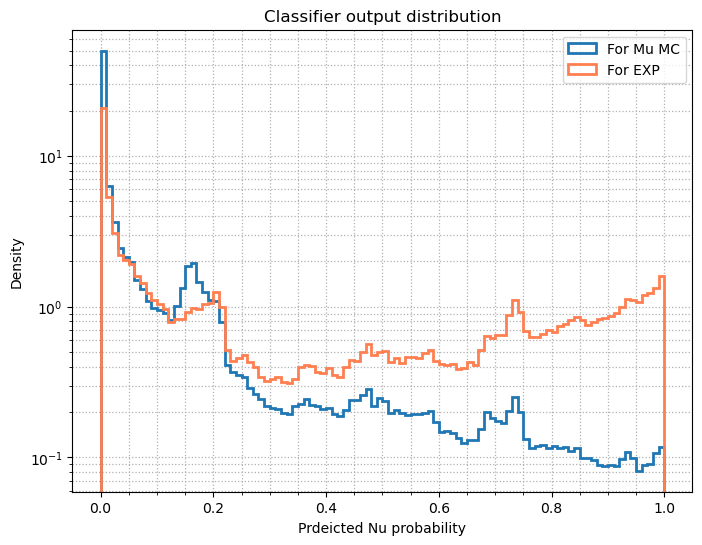

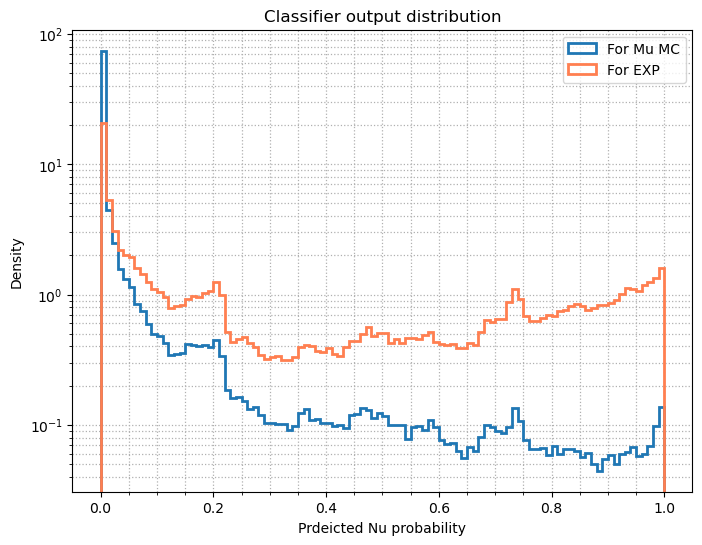

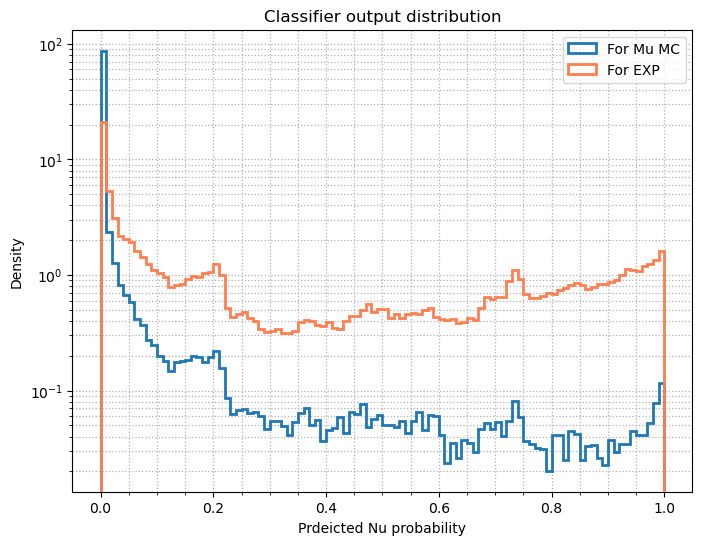

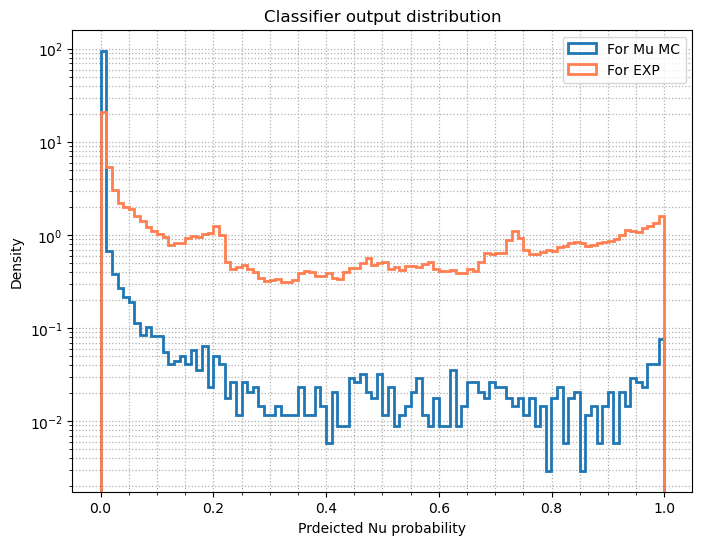

In [10]:
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    
    plt.figure(figsize=(8,6))
    plt.hist(probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Mu MC')
    plt.hist(exp_probabilities, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label='For EXP')
    plt.title("Classifier output distribution")
    plt.legend()
    plt.grid(which='both', ls=':', lw=0.9)

    plt.xlabel("Prdeicted Nu probability")
    plt.ylabel("Density")
    plt.minorticks_on()
    
    p_distr_fig = plt.gcf()
    p_distr_fig.savefig(f"{fig_dir}/MC_EXP_p_distr_h{h}_s{s}.png")
    plt.show()
    plt.close()

# 5. Feature Space Analysis: MC vs Experimental

## 5.1 UMAP Visualization of MC vs Experimental Features

In [18]:
# UMAP visualization of MC vs Experimental feature distributions (Baseline Model)
print("=== UMAP Analysis of Feature Space (Baseline Model) ===")

# Install umap if not available (uncomment if needed)
# !pip install umap-learn

import umap
from matplotlib.patches import Patch

# Prepare data for UMAP visualization
print("Preparing data for UMAP visualization...")

# Use a subset for visualization (UMAP can be slow on large datasets)
n_viz_samples = 10000  # Adjust based on computational resources
n_mc_viz = min(n_viz_samples // 2, len(features))
n_exp_viz = min(n_viz_samples // 2, len(exp_features))

# Sample MC features (muons only to balance with unlabeled experimental)
mc_muon_indices = np.where(~labels)[0]  # Get muon events
n_mc_muon_available = len(mc_muon_indices)
n_mc_viz = min(n_mc_viz, n_mc_muon_available)

mc_viz_indices = np.random.choice(mc_muon_indices, n_mc_viz, replace=False)
mc_viz_features = features[mc_viz_indices]

# Sample experimental features
exp_viz_indices = np.random.choice(len(exp_features), n_exp_viz, replace=False)
exp_viz_features = exp_features[exp_viz_indices]

# Combine for UMAP fitting
all_viz_features = np.concatenate([mc_viz_features, exp_viz_features], axis=0)
domain_viz_labels = np.concatenate([
    np.zeros(n_mc_viz),   # 0 = MC
    np.ones(n_exp_viz)    # 1 = Experimental
], axis=0)

print(f"UMAP visualization data:")
print(f"- MC samples: {n_mc_viz:,}")
print(f"- Experimental samples: {n_exp_viz:,}")
print(f"- Total samples: {len(all_viz_features):,}")
print(f"- Feature dimension: {all_viz_features.shape[1]}")

# Configure UMAP parameters
umap_params = {
    'n_neighbors': 25,      # Local neighborhood size
    'min_dist': 0.05,        # Minimum distance between points
    'n_components': 2,      # 2D embedding
    'metric': 'euclidean',  # Distance metric
    'random_state': 42      # Reproducibility
}

print(f"\nUMAP parameters: {umap_params}")
print("Fitting UMAP (this may take a moment)...")

# Fit UMAP
reducer = umap.UMAP(**umap_params)
embedding = reducer.fit_transform(all_viz_features)

print("UMAP fitting completed!")

# Split embedding back to MC and Experimental
mc_embedding = embedding[:n_mc_viz]
exp_embedding = embedding[n_mc_viz:]

print(f"Embedding shape: {embedding.shape}")
print(f"MC embedding: {mc_embedding.shape}")
print(f"Experimental embedding: {exp_embedding.shape}")

=== UMAP Analysis of Feature Space (Baseline Model) ===
Preparing data for UMAP visualization...
UMAP visualization data:
- MC samples: 5,000
- Experimental samples: 5,000
- Total samples: 10,000
- Feature dimension: 128

UMAP parameters: {'n_neighbors': 25, 'min_dist': 0.05, 'n_components': 2, 'metric': 'euclidean', 'random_state': 42}
Fitting UMAP (this may take a moment)...


/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fitting completed!
Embedding shape: (10000, 2)
MC embedding: (5000, 2)
Experimental embedding: (5000, 2)


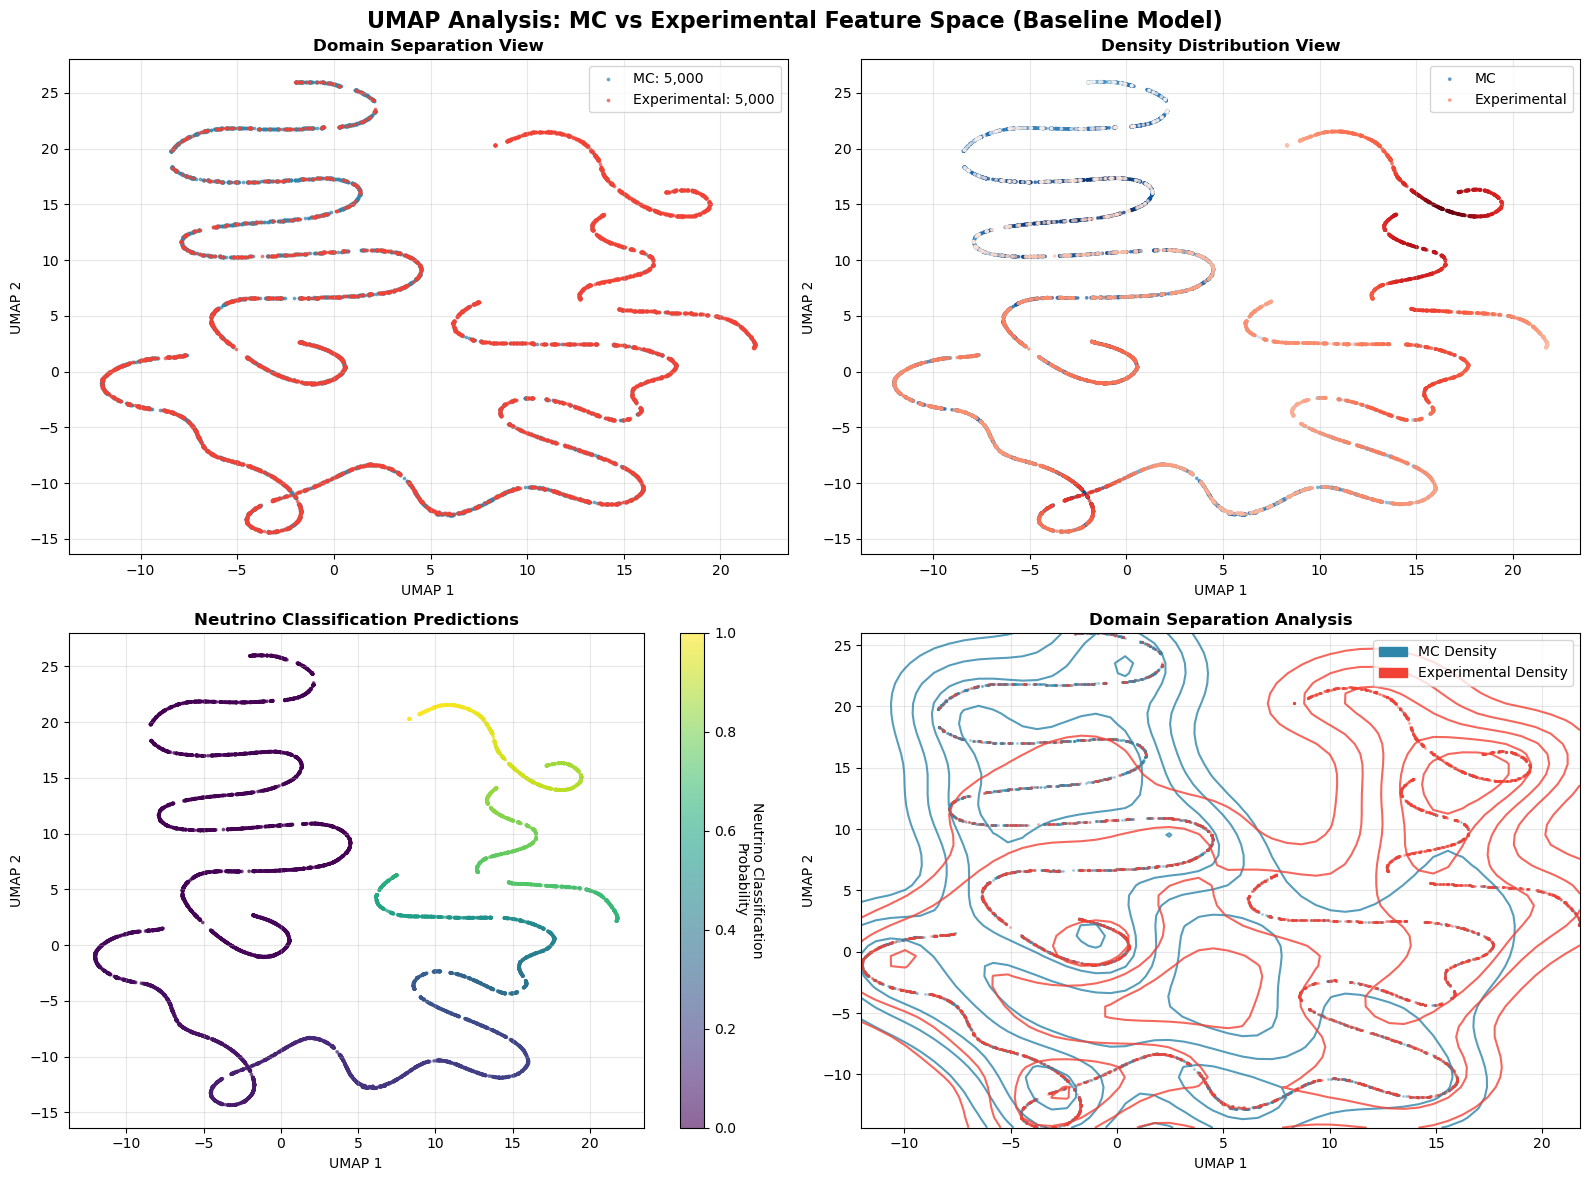


=== UMAP Feature Space Analysis (Baseline Model) ===
Feature space metrics:
- MC cluster center: (0.63, 4.37)
- Experimental cluster center: (6.43, 3.46)
- Center distance: 5.868
- Average spread: 12.904
- Separation ratio: 0.455 (higher = more separated)
- Baseline model assessment: ✅ MINIMAL domain separation - domains well mixed

Neutrino classification comparison:
- MC neutrino prediction rate: 0.105
- Experimental neutrino prediction rate: 0.366
- Prediction difference: 0.260
- Prediction consistency: ❌ Large prediction difference - domain bias detected

=== Summary (Baseline Model) ===
This baseline model (without domain adaptation) shows:
- Domain separation level: 0.455
- Prediction difference: 0.260
- Overall domain independence: POOR

Baseline UMAP analysis completed! Visualization saved to:
../experiments/numu/baseline_251010_middle_2/report_BigMCSample_EqualAtmAtsro/figures//umap_baseline_feature_analysis.png


: 

In [ ]:
# Create comprehensive UMAP visualizations for baseline model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('UMAP Analysis: MC vs Experimental Feature Space (Baseline Model)', fontsize=16, fontweight='bold')

# Colors and styling
mc_color = '#2E86AB'      # Blue for MC
exp_color = '#F24236'     # Red for Experimental
alpha = 0.6
point_size = 3

# Plot 1: Basic domain separation
ax1 = axes[0, 0]
scatter1 = ax1.scatter(mc_embedding[:, 0], mc_embedding[:, 1], 
                      c=mc_color, alpha=alpha, s=point_size, label=f'MC: {n_mc_viz:,}')
scatter2 = ax1.scatter(exp_embedding[:, 0], exp_embedding[:, 1], 
                      c=exp_color, alpha=alpha, s=point_size, label=f'Experimental: {n_exp_viz:,}')
ax1.set_title('Domain Separation View', fontweight='bold')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Density-based visualization
ax2 = axes[0, 1]
# Create density plots
from scipy.stats import gaussian_kde

# Calculate point density for color mapping
mc_xy = mc_embedding.T
exp_xy = exp_embedding.T

# MC density
if len(mc_xy[0]) > 1:
    mc_density = gaussian_kde(mc_xy)(mc_xy)
    mc_density = mc_density / mc_density.max()
else:
    mc_density = np.ones(len(mc_xy[0]))

# Experimental density  
if len(exp_xy[0]) > 1:
    exp_density = gaussian_kde(exp_xy)(exp_xy)
    exp_density = exp_density / exp_density.max()
else:
    exp_density = np.ones(len(exp_xy[0]))

scatter3 = ax2.scatter(mc_embedding[:, 0], mc_embedding[:, 1], 
                      c=mc_density, cmap='Blues', s=point_size, alpha=alpha, label='MC')
scatter4 = ax2.scatter(exp_embedding[:, 0], exp_embedding[:, 1], 
                      c=exp_density, cmap='Reds', s=point_size, alpha=alpha, label='Experimental')
ax2.set_title('Density Distribution View', fontweight='bold')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Neutrino classification predictions overlay
ax3 = axes[1, 0]
# Get neutrino predictions for visualization samples
with torch.no_grad():
    model.eval()
    # For MC samples, we can use the existing predictions
    mc_viz_probs = probabilities[mc_viz_indices]
    # For experimental samples, use the experimental predictions
    exp_viz_probs = exp_probabilities[exp_viz_indices]

# Color by neutrino prediction probability
all_viz_probs = np.concatenate([mc_viz_probs, exp_viz_probs])
scatter5 = ax3.scatter(embedding[:, 0], embedding[:, 1], 
                      c=all_viz_probs, cmap='viridis', s=point_size, 
                      alpha=alpha, vmin=0, vmax=1)
cbar = plt.colorbar(scatter5, ax=ax3)
cbar.set_label('Neutrino Classification\nProbability', rotation=270, labelpad=20)
ax3.set_title('Neutrino Classification Predictions', fontweight='bold')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)

# Plot 4: Domain separation analysis with contours
ax4 = axes[1, 1]
# Create contour plots to show domain separation
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

# Kernel density estimation for contours
if len(mc_embedding) > 10 and len(exp_embedding) > 10:
    mc_kde = gaussian_kde(mc_embedding.T)
    exp_kde = gaussian_kde(exp_embedding.T)
    
    # Create grid for contour plots
    x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
    y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    mc_density_grid = mc_kde(positions).reshape(xx.shape)
    exp_density_grid = exp_kde(positions).reshape(xx.shape)
    
    # Plot contours
    mc_contour = ax4.contour(xx, yy, mc_density_grid, colors=[mc_color], alpha=0.8, levels=5)
    exp_contour = ax4.contour(xx, yy, exp_density_grid, colors=[exp_color], alpha=0.8, levels=5)
    
    # Add scatter points
    ax4.scatter(mc_embedding[:, 0], mc_embedding[:, 1], 
               c=mc_color, alpha=0.3, s=point_size/2, label='MC')
    ax4.scatter(exp_embedding[:, 0], exp_embedding[:, 1], 
               c=exp_color, alpha=0.3, s=point_size/2, label='Experimental')
    
    # Create legend with patches
    mc_patch = mpatches.Patch(color=mc_color, label='MC Density')
    exp_patch = mpatches.Patch(color=exp_color, label='Experimental Density')
    ax4.legend(handles=[mc_patch, exp_patch])
else:
    # Fallback if too few points
    ax4.scatter(mc_embedding[:, 0], mc_embedding[:, 1], 
               c=mc_color, alpha=alpha, s=point_size, label='MC')
    ax4.scatter(exp_embedding[:, 0], exp_embedding[:, 1], 
               c=exp_color, alpha=alpha, s=point_size, label='Experimental')
    ax4.legend()

ax4.set_title('Domain Separation Analysis', fontweight='bold')
ax4.set_xlabel('UMAP 1')
ax4.set_ylabel('UMAP 2')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/umap_baseline_feature_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate domain separation metrics
print("\n=== UMAP Feature Space Analysis (Baseline Model) ===")

# Calculate center distances
mc_center = np.mean(mc_embedding, axis=0)
exp_center = np.mean(exp_embedding, axis=0)
center_distance = np.linalg.norm(mc_center - exp_center)

# Calculate spread (average distance from center)
mc_spread = np.mean(np.linalg.norm(mc_embedding - mc_center, axis=1))
exp_spread = np.mean(np.linalg.norm(exp_embedding - exp_center, axis=1))
avg_spread = (mc_spread + exp_spread) / 2

# Separation ratio (opposite of overlap - higher means more separated)
separation_ratio = center_distance / avg_spread

print(f"Feature space metrics:")
print(f"- MC cluster center: ({mc_center[0]:.2f}, {mc_center[1]:.2f})")
print(f"- Experimental cluster center: ({exp_center[0]:.2f}, {exp_center[1]:.2f})")
print(f"- Center distance: {center_distance:.3f}")
print(f"- Average spread: {avg_spread:.3f}")
print(f"- Separation ratio: {separation_ratio:.3f} (higher = more separated)")

# Interpretation for baseline model (without domain adaptation)
if separation_ratio > 2.0:
    separation_verdict = "❌ HIGH domain separation - domains clearly distinct"
elif separation_ratio > 1.0:
    separation_verdict = "⚠️ MODERATE domain separation - some distinction"  
elif separation_ratio > 0.5:
    separation_verdict = "✅ LOW domain separation - domains partially mixed"
else:
    separation_verdict = "✅ MINIMAL domain separation - domains well mixed"

print(f"- Baseline model assessment: {separation_verdict}")

# Classification performance comparison
mc_neutrino_rate = np.mean(mc_viz_probs)
exp_neutrino_rate = np.mean(exp_viz_probs)
prediction_difference = abs(mc_neutrino_rate - exp_neutrino_rate)

print(f"\nNeutrino classification comparison:")
print(f"- MC neutrino prediction rate: {mc_neutrino_rate:.3f}")
print(f"- Experimental neutrino prediction rate: {exp_neutrino_rate:.3f}")
print(f"- Prediction difference: {prediction_difference:.3f}")

if prediction_difference < 0.05:
    pred_verdict = "✅ Similar predictions across domains"
elif prediction_difference < 0.1:
    pred_verdict = "⚠️ Moderate prediction difference"
else:
    pred_verdict = "❌ Large prediction difference - domain bias detected"

print(f"- Prediction consistency: {pred_verdict}")

print(f"\n=== Summary (Baseline Model) ===")
print(f"This baseline model (without domain adaptation) shows:")
print(f"- Domain separation level: {separation_ratio:.3f}")
print(f"- Prediction difference: {prediction_difference:.3f}")
print(f"- Overall domain independence: {'GOOD' if separation_ratio < 1.0 and prediction_difference < 0.1 else 'POOR'}")

print(f"\nBaseline UMAP analysis completed! Visualization saved to:")
print(f"{fig_dir}/umap_baseline_feature_analysis.png")

In [17]:
# Check feature correlations
correlation_matrix = np.corrcoef(features.T)
print(f"Mean absolute correlation: {np.abs(correlation_matrix).mean():.3f}")

# Check feature variance
feature_vars = np.var(features, axis=0)
print(f"Feature variance range: {feature_vars.min():.3f} - {feature_vars.max():.3f}")

# Check if features are dominated by one component
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(features)
print(f"First PC explains {pca.explained_variance_ratio_[0]:.1%} of variance")

Mean absolute correlation: 0.680
Feature variance range: 0.029 - 1.118
First PC explains 79.0% of variance
